#### Assignment #1 - Part 1 - Average Salary of Teachers in Chicago
-   Data cleansing 
-   Select the right rows for teachers 
-   Delete na values or impute 
-   Winsorze for outliers and compute summary stats

In [152]:
import pandas as pd
import numpy as np
from scipy.stats import mstats
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy
import pandas
import random
import sys

import seaborn
from datetime import datetime

In [153]:
tt = pandas.read_csv(r'G:\My Drive\PROFESSIONAL\MAS24\Courses\CSP571\data\\Online_Retail.csv')
tt['InvoiceDate'] = pandas.to_datetime(tt['InvoiceDate'], format='%m/%d/%Y %H:%M')
print('shape:',tt.shape)
# cust id missing 22
print((tt.isnull().sum() / tt.shape[0])*100)

shape: (1048575, 8)
Invoice         0.000000
StockCode       0.000000
Description     0.416947
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.571776
Country         0.000000
dtype: float64


In [196]:
# cust id missing - delete 
ttt = tt[~tt['Customer ID'].isna()].copy()

print('Before dups', ttt.shape)
ttt.drop_duplicates(inplace=True)
print('After del duplicates', ttt.shape)

# invoice that start with C
print ('Cancellations:',ttt["Invoice"].str.startswith("C").sum())
print ('Cancellations %:',(ttt["Invoice"].str.startswith("C").sum() / ttt.shape[0])*100)

# del cancellations
ttt = ttt[~ttt["Invoice"].str.startswith("C")]


# get amount per line
ttt['Amount'] = ttt['Quantity'] * ttt['Price']

# rows with negative amount
print('rows with negative amount', ttt[ttt['Amount'] <0].shape[0])

# rows with negative amount
print('rows final', ttt.shape[0])

# positive amount 
print('Quantity less than equal  0 :',(ttt["Quantity"] <= 0).sum())


# positive amount 
print('Price less than equal to 0 :',(ttt["Price"] <= 0).sum())

# delete 0 price rows
ttt = ttt[ttt["Price"] > 0]
print('rows after price = 0 fix' , ttt.shape[0])
# unique country
print('Unique country:', ttt['Country'].nunique())
print('Unique country:', sorted(ttt['Country'].unique()))

Before dups (811893, 8)
After del duplicates (785599, 8)
Cancellations: 18160
Cancellations %: 2.3116119037829734
rows with negative amount 0
rows final 767439
Quantity less than equal  0 : 0
Price less than equal to 0 : 70
rows after price = 0 fix 767369
Unique country: 41
Unique country: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']


In [169]:
### RFM Analysis


In [197]:
print(ttt.columns)
cols_to_keep = ['Customer ID', 'StockCode', 'InvoiceDate','Amount', 'Country']
transaction = ttt[cols_to_keep].copy()
transaction.columns = ['CustomerID', 'StockCode', 'Date', 'Amount', 'Country']
transaction.sort_values(by=[ 'Date','CustomerID'], inplace=True)

# recency date - get dates by refence - data starts 1 Dec 2009 - use 30 Nov as ref date
t_date = pd.to_datetime(transaction['Date'], format='%m/%d/%Y')
reference_date = datetime.strptime('11/30/2009', "%m/%d/%Y")
n_days = pandas.Series((t_date - reference_date) / numpy.timedelta64(1, 'D'), name = 'N Days')

train_data = transaction[['CustomerID', 'Date', 'Amount', 'Country']].join(n_days)
train_data.tail()



Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Amount'],
      dtype='object')


,CustomerID,Date,Amount,Country,N Days
1048570,14546.0,2011-12-04 13:00:00,16.50,United Kingdom,734.541667
1048571,14546.0,2011-12-04 13:00:00,14.85,United Kingdom,734.541667
1048572,16931.0,2011-12-04 13:15:00,4.95,United Kingdom,734.552083
1048573,16931.0,2011-12-04 13:15:00,5.78,United Kingdom,734.552083
1048574,16931.0,2011-12-04 13:15:00,6.65,United Kingdom,734.552083


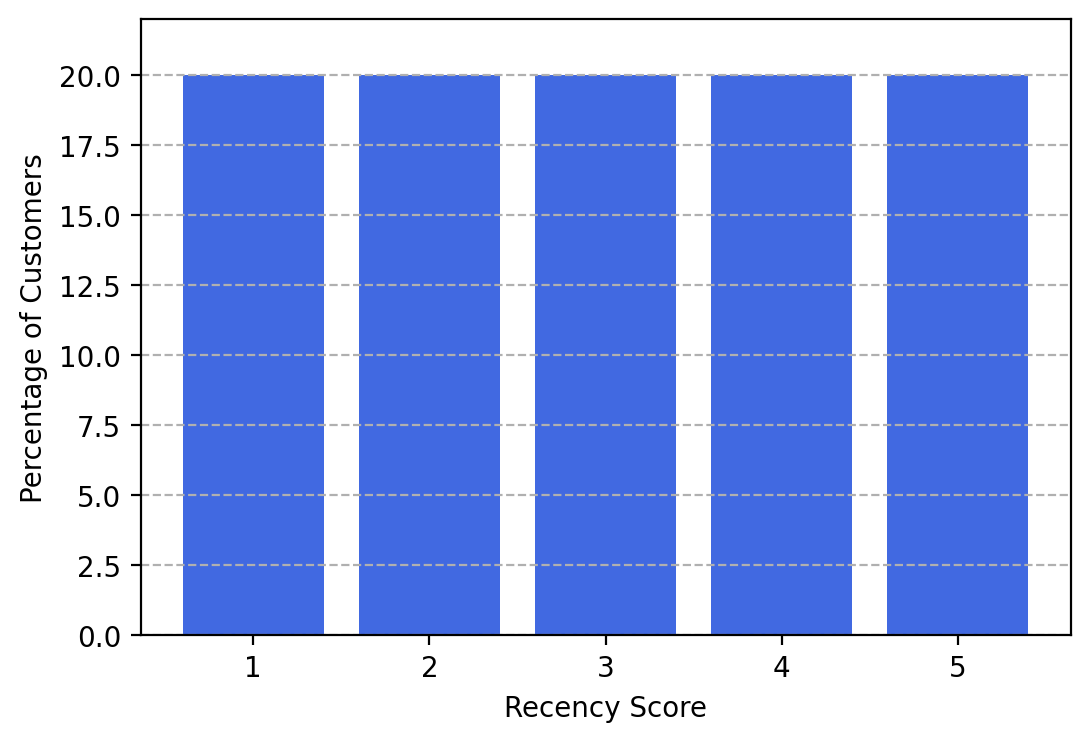

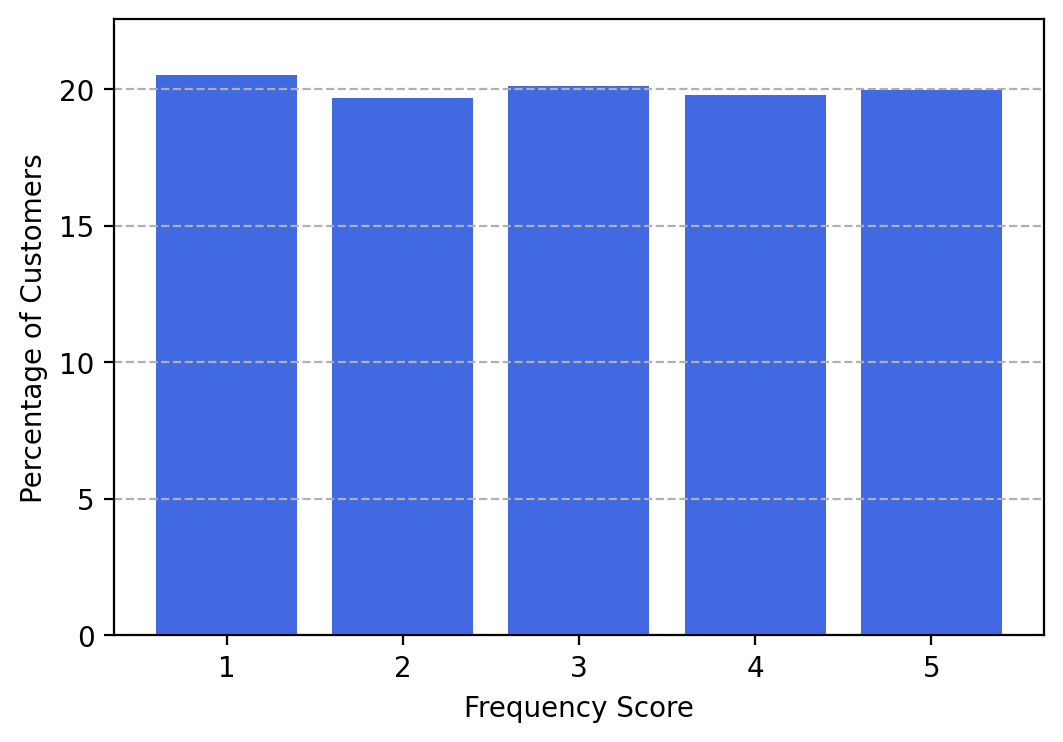

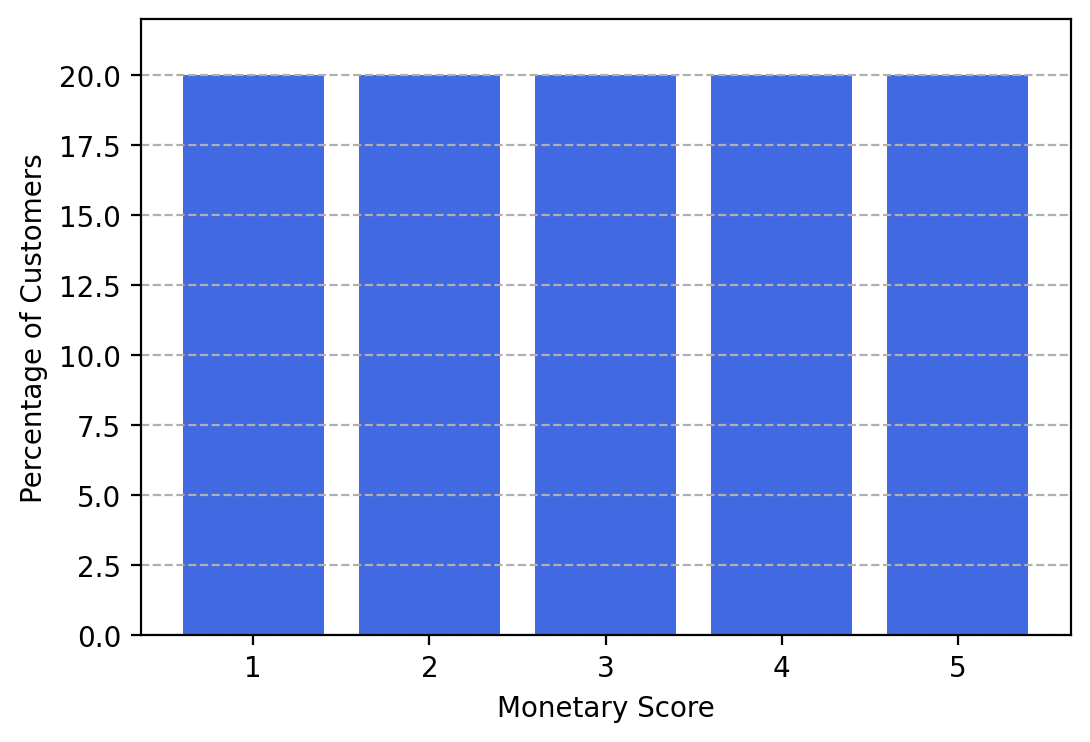

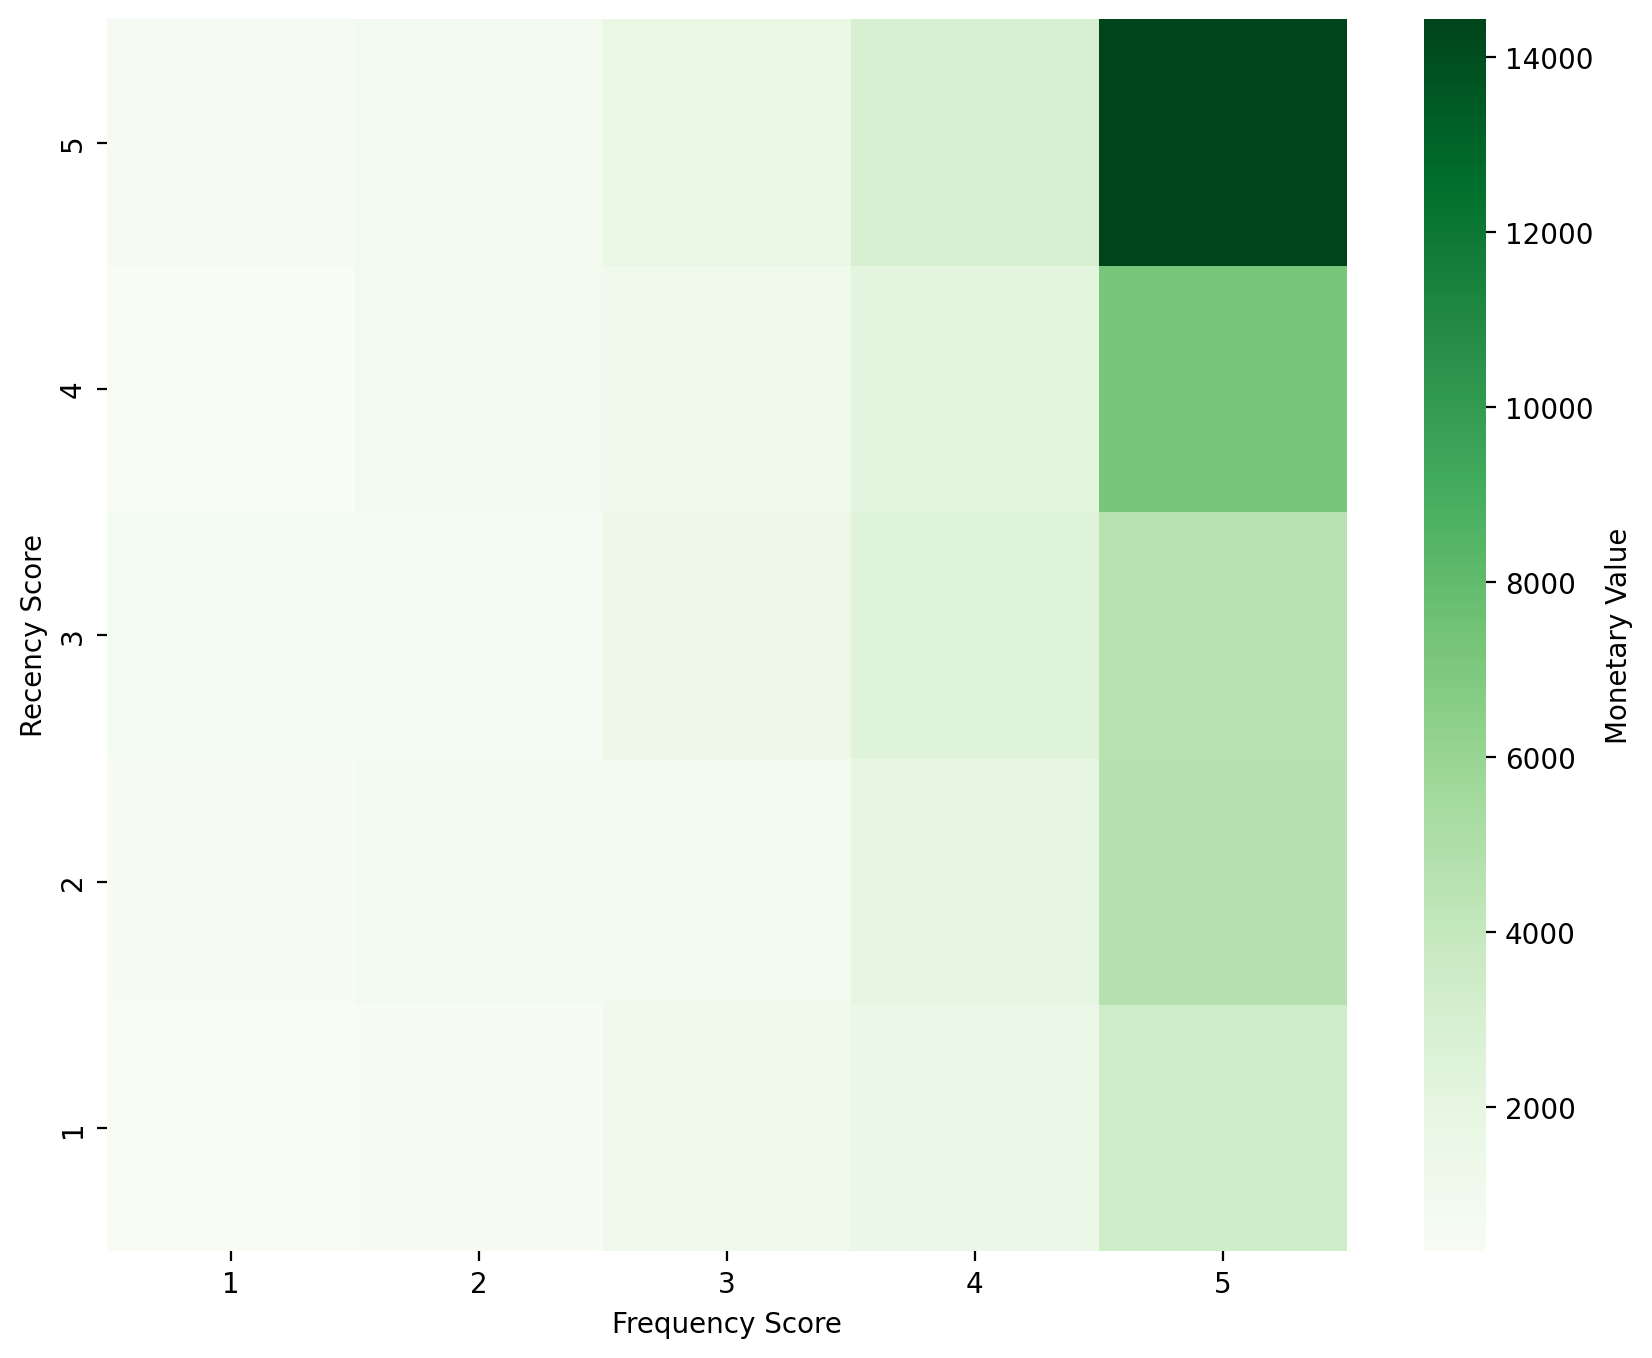

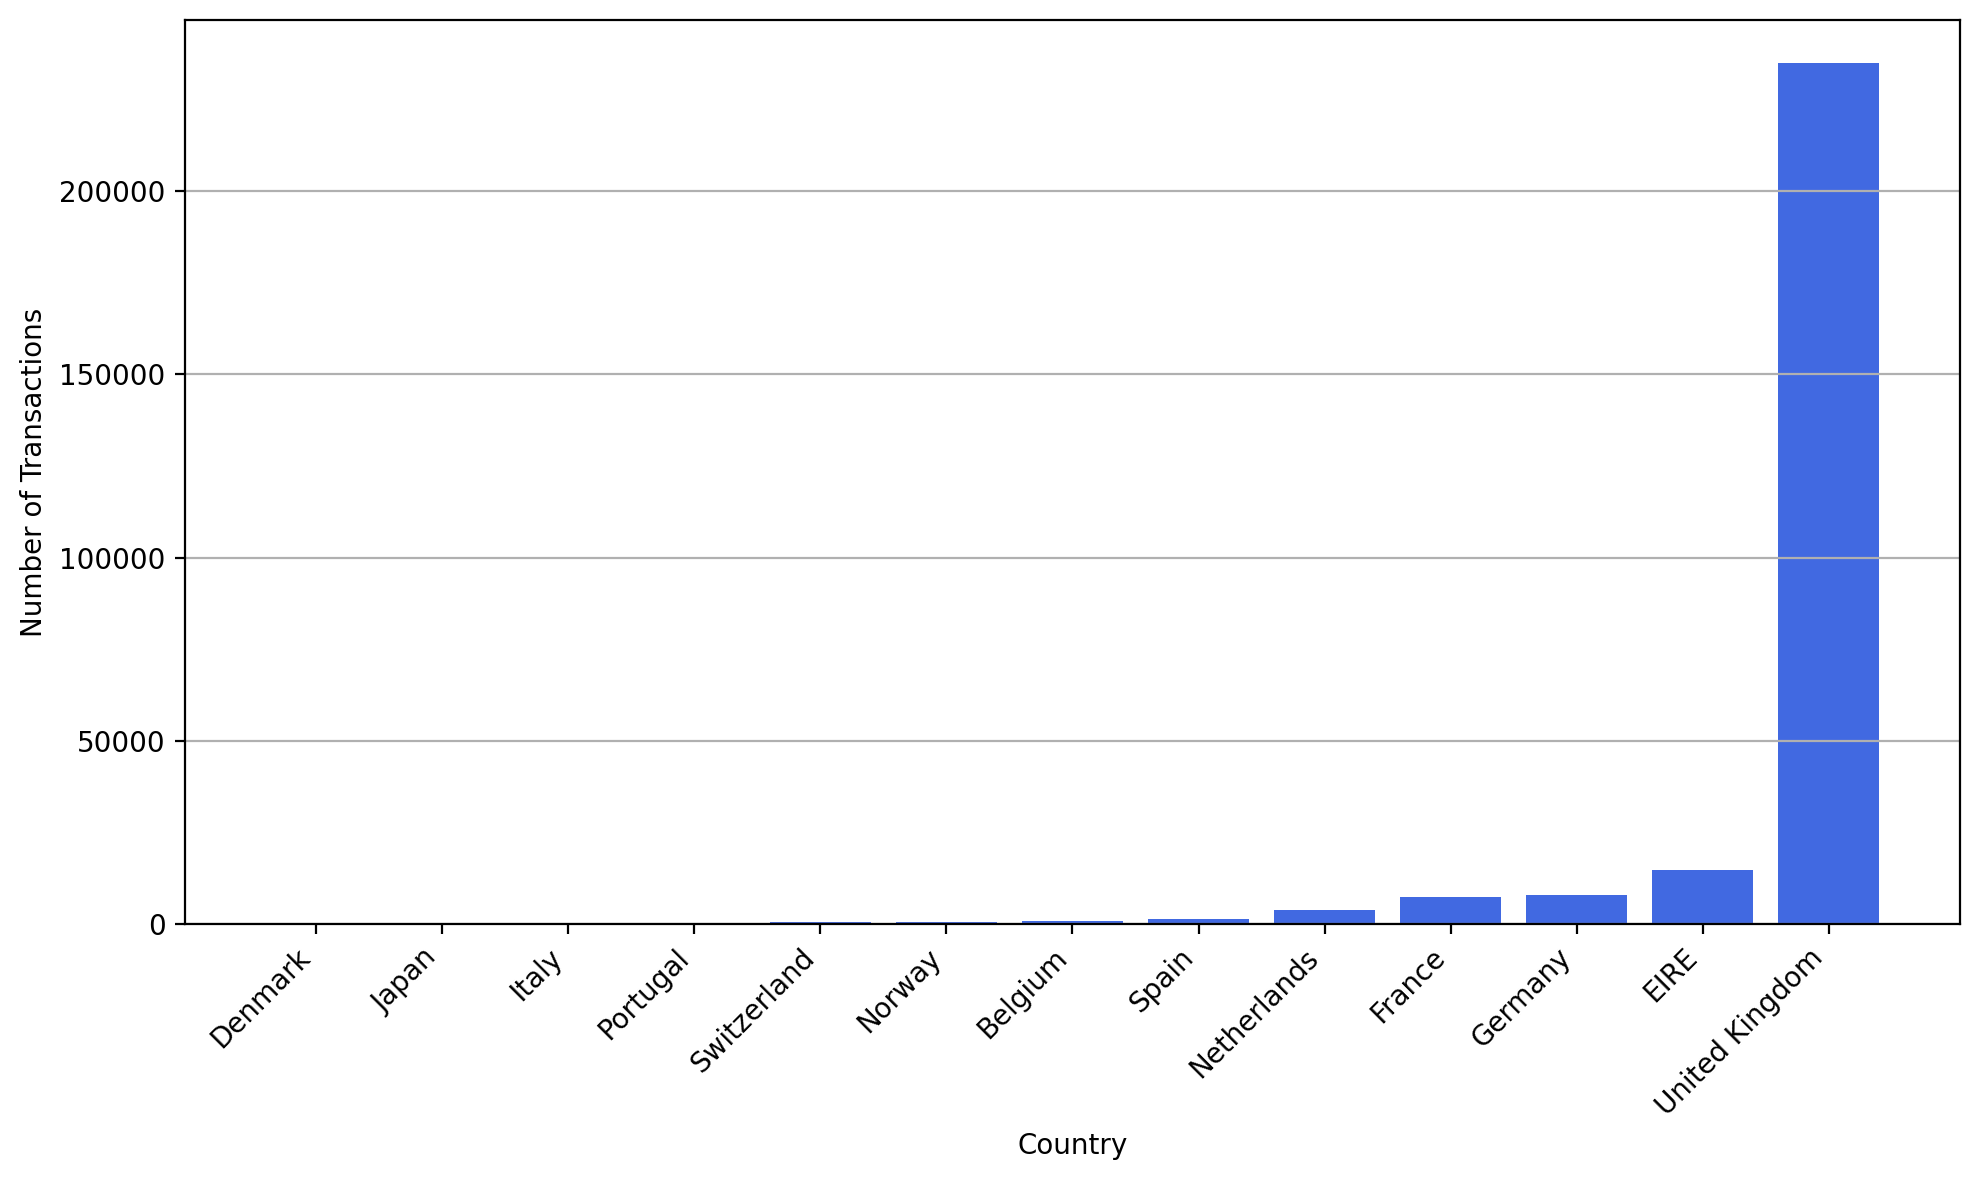

In [204]:

# Define the aggregation procedure outside of the groupby operation
aggregations = {
    'N Days':'max',
    'CustomerID': 'count',
    'Amount': 'sum'
}

column_map = {'N Days': 'Recency', 'CustomerID': 'Frequency', 'Amount': 'Monetary'}

customer_data = train_data.groupby('CustomerID').agg(aggregations).rename(columns = column_map)
rfm_names = customer_data.columns


# Determine the quintiles
quintile = customer_data.describe(percentiles = [0.2, 0.4, 0.6, 0.8])
quintile


# Assign customers to groups
customer_group = pandas.DataFrame(numpy.where(numpy.isnan(customer_data),0,1), index = customer_data.index)

for q in ['20%','40%','60%','80%']:
   customer_group = customer_group + numpy.where(customer_data[rfm_names] > quintile.loc[q][rfm_names], 1, 0)

customer_group = customer_group.rename(columns = {0: 'Recency Score', 1: 'Frequency Score', 2: 'Monetary Score'})


# Inspect bar charts of each group
for g in ['Recency Score', 'Frequency Score','Monetary Score']:
   group_prop = 100 * customer_group[g].value_counts(ascending = True, normalize = True)

   plt.figure(figsize = (6,4), dpi = 200)
   plt.bar(group_prop.index, group_prop, color = 'royalblue')
   plt.xlabel(g)
   plt.ylabel('Percentage of Customers')
   plt.xticks(range(1,6,1))
   plt.grid(axis = 'y', linestyle = '--')
   plt.margins(y = 0.1)
   plt.show()

# Merge the group assignments back to the customer data
customer_data = customer_data.join(customer_group)

customer_data['RFM Score'] = 100 * customer_data['Recency Score'] + 10 * customer_data['Frequency Score'] + customer_data['Monetary Score']

# Look at Monetary value by Recency and Frequency groups
xtab = pandas.crosstab(index = customer_data['Recency Score'], columns = customer_data['Frequency Score'],
                       values = customer_data['Monetary'], aggfunc = 'mean')
plt.figure(figsize = (10,8), dpi = 200)
seaborn.heatmap(xtab, cmap = 'Greens', cbar_kws={'label': 'Monetary Value'})
plt.gca().invert_yaxis()
plt.show()

# Copy the RFM Score back to the transaction data
transaction_rfm = transaction.merge(customer_data['RFM Score'], left_on = ['CustomerID'], right_on = customer_data.index)


# Copy the RFM Score back to the transaction data
transaction_rfm = transaction.merge(customer_data['RFM Score'], left_on = ['CustomerID'], right_on = customer_data.index)

# What kind of products do the customers with RFM score 555 buy?
focus_data = transaction_rfm[transaction_rfm['RFM Score'] == 555]

product_size = focus_data['Country'].value_counts(ascending = True)

plt.figure(figsize = (10,6), dpi = 200)
plt.bar(product_size.index, product_size, color = 'royalblue')
plt.xticks(rotation=45, ha='right')
# plt.yticks(range(0,100,10))
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()


In [200]:
quintile['Recency']

count    5860.000000
mean      534.086227
std       207.494130
min         1.413194
20%       328.660694
40%       543.436528
50%       633.632639
60%       676.008889
80%       715.673750
max       734.552083
Name: Recency, dtype: float64

In [201]:
quintile['Frequency']

count     5860.000000
mean       130.950341
std        335.065777
min          1.000000
20%         16.000000
40%         36.000000
50%         52.000000
60%         74.000000
80%        171.000000
max      12121.000000
Name: Frequency, dtype: float64

In [202]:
quintile['Monetary']

count      5860.000000
mean       2893.669104
std       14052.386048
min           2.900000
20%         282.838000
40%         602.602000
50%         854.380000
60%        1208.560000
80%        2868.120000
max      569501.500000
Name: Monetary, dtype: float64

In [203]:
transaction_rfm

,CustomerID,StockCode,Date,Amount,Country,RFM Score
0,13085.0,85048,2009-12-01 07:45:00,83.40,United Kingdom,344
1,13085.0,79323P,2009-12-01 07:45:00,81.00,United Kingdom,344
2,13085.0,79323W,2009-12-01 07:45:00,81.00,United Kingdom,344
3,13085.0,22041,2009-12-01 07:45:00,100.80,United Kingdom,344
4,13085.0,21232,2009-12-01 07:45:00,30.00,United Kingdom,344
...,...,...,...,...,...,...
767364,14546.0,23284,2011-12-04 13:00:00,16.50,United Kingdom,555
767365,14546.0,22507,2011-12-04 13:00:00,14.85,United Kingdom,555
767366,16931.0,22469,2011-12-04 13:15:00,4.95,United Kingdom,555
767367,16931.0,23489,2011-12-04 13:15:00,5.78,United Kingdom,555


In [175]:
print("RECENCY Cutoffs (N Days):")
print(f"  20th percentile: {quintile.loc['20%', 'Recency']:.2f}")
print(f"  40th percentile: {quintile.loc['40%', 'Recency']:.2f}")
print(f"  60th percentile: {quintile.loc['60%', 'Recency']:.2f}")
print(f"  80th percentile: {quintile.loc['80%', 'Recency']:.2f}")
print()

print("FREQUENCY Cutoffs (Number of Transactions):")
print(f"  20th percentile: {quintile.loc['20%', 'Frequency']:.2f}")
print(f"  40th percentile: {quintile.loc['40%', 'Frequency']:.2f}")
print(f"  60th percentile: {quintile.loc['60%', 'Frequency']:.2f}")
print(f"  80th percentile: {quintile.loc['80%', 'Frequency']:.2f}")
print()

print("MONETARY Cutoffs (Total Amount Spent):")
print(f"  20th percentile: {quintile.loc['20%', 'Monetary']:.2f}")
print(f"  40th percentile: {quintile.loc['40%', 'Monetary']:.2f}")
print(f"  60th percentile: {quintile.loc['60%', 'Monetary']:.2f}")
print(f"  80th percentile: {quintile.loc['80%', 'Monetary']:.2f}")

RECENCY Cutoffs (N Days):
  20th percentile: 328.63
  40th percentile: 543.29
  60th percentile: 675.90
  80th percentile: 715.68

FREQUENCY Cutoffs (Number of Transactions):
  20th percentile: 16.00
  40th percentile: 36.00
  60th percentile: 74.00
  80th percentile: 171.00

MONETARY Cutoffs (Total Amount Spent):
  20th percentile: 282.48
  40th percentile: 601.87
  60th percentile: 1207.51
  80th percentile: 2867.41


In [176]:
customer_group

,Recency Score,Frequency Score,Monetary Score
CustomerID,,,
12346.0,2,2,5
12347.0,4,5,5
12348.0,3,3,4
12349.0,5,5,5
12350.0,2,2,2
...,...,...,...
18283.0,5,5,4
18284.0,1,2,2
18285.0,1,1,2


In [188]:
customer_data.sort_values('Frequency', ascending=False)

,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetary Score,RFM Score
CustomerID,,,,,,,
17841.0,732.575694,12121,66746.66,5,5,5,555
14911.0,731.743750,10794,285118.84,5,5,5,555
12748.0,734.521528,6388,52838.66,5,5,5,555
14606.0,730.583333,6261,29609.53,5,5,5,555
14096.0,728.662500,4582,56228.81,5,5,5,555
...,...,...,...,...,...,...,...
12570.0,57.727778,1,77.52,1,1,1,111
15118.0,605.620833,1,244.80,3,1,1,311
12636.0,1.413194,1,141.00,1,1,1,111


Number of transactions by country for RFM Score 555:
Country
United Kingdom    234953
EIRE               14830
Germany             8060
France              7448
Netherlands         3763
Spain               1481
Belgium              710
Norway               669
Switzerland          511
Portugal             364
Italy                347
Japan                197
Denmark               10
Name: count, dtype: int64


Statistics by Country for RFM Score 555 Customers:
                 count        mean  median         std     min       max
Country                                                                 
Netherlands       3763  137.357029  105.60  159.682519   0.390   4992.00
Japan              197  108.778629  100.80   72.444631  15.300    429.60
Denmark             10   76.860000   55.92   52.661280  25.920    165.00
Switzerland        511   24.794286   19.80   19.641049   2.880    244.80
Belgium            710   26.006704   17.70   60.067180   2.500   1508.65
Norway             669  

<Figure size 2800x1200 with 0 Axes>

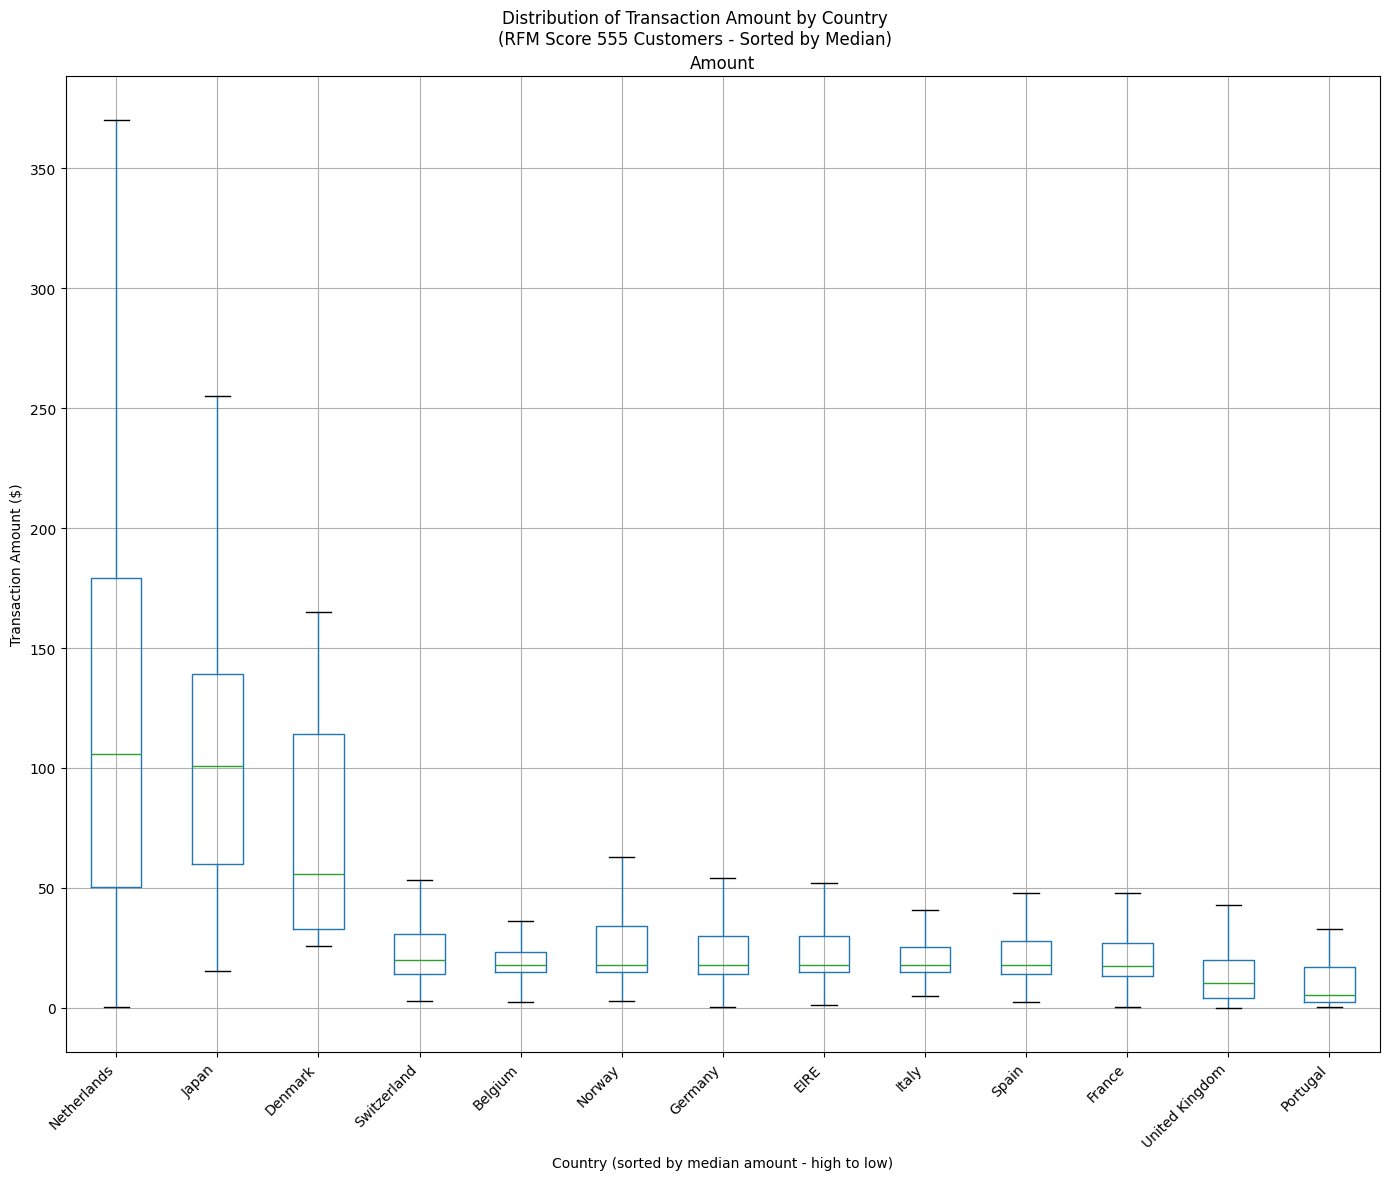


Countries with HIGHEST median transaction amount:
             median         std
Country                        
Netherlands  105.60  159.682519
Japan        100.80   72.444631
Denmark       55.92   52.661280
Switzerland   19.80   19.641049
Belgium       17.70   60.067180

Countries with LARGEST variation (standard deviation) in transaction amount:
                       std  median
Country                           
Netherlands     159.682519   105.6
Portugal        100.400464     5.1
EIRE             98.663452    17.7
United Kingdom   92.117540    10.2
Japan            72.444631   100.8


In [210]:
# Create boxplot of transaction amount by country for RFM Score 555 customers
focus_data = transaction_rfm[transaction_rfm['RFM Score'] == 555]

# Get countries with transactions and sort by count
country_counts = focus_data['Country'].value_counts()
print(f"Number of transactions by country for RFM Score 555:")
print(country_counts)
print()

# Calculate statistics by country FIRST
print("\nStatistics by Country for RFM Score 555 Customers:")
country_stats = focus_data.groupby('Country')['Amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
country_stats = country_stats.sort_values('median', ascending=False)  # Sort by median (high to low)
print(country_stats)
print()

# Reorder focus_data by countries sorted by median
country_order = country_stats.index.tolist()
focus_data_ordered = focus_data.copy()
focus_data_ordered['Country'] = pandas.Categorical(focus_data_ordered['Country'], categories=country_order, ordered=True)
focus_data_ordered = focus_data_ordered.sort_values('Country')

# Create boxplot sorted by median (high to low)
plt.figure(figsize=(14, 6), dpi=200)
focus_data_ordered.boxplot(column='Amount', by='Country', figsize=(14, 12), showfliers=False)
plt.suptitle('Distribution of Transaction Amount by Country\n(RFM Score 555 Customers - Sorted by Median)', fontsize=12)
plt.xlabel('Country (sorted by median amount - high to low)')
plt.ylabel('Transaction Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCountries with HIGHEST median transaction amount:")
print(country_stats.nlargest(5, 'median')[['median', 'std']])
print()

print("Countries with LARGEST variation (standard deviation) in transaction amount:")
print(country_stats.nlargest(5, 'std')[['std', 'median']])

In [211]:
# Number of observations in each bucket for Recency and Frequency
print("="*60)
print("NUMBER OF OBSERVATIONS IN EACH QUINTILE BUCKET")
print("="*60)
print()

print("RECENCY SCORE - Number of Customers in Each Bucket:")
recency_counts = customer_group['Recency Score'].value_counts().sort_index()
print(recency_counts)
print(f"Total: {recency_counts.sum()}")
print()

print("FREQUENCY SCORE - Number of Customers in Each Bucket:")
frequency_counts = customer_group['Frequency Score'].value_counts().sort_index()
print(frequency_counts)
print(f"Total: {frequency_counts.sum()}")
print()

print("MONETARY SCORE - Number of Customers in Each Bucket:")
monetary_counts = customer_group['Monetary Score'].value_counts().sort_index()
print(monetary_counts)
print(f"Total: {monetary_counts.sum()}")
print()

# Create a summary dataframe
summary_df = pandas.DataFrame({
    'Recency': recency_counts,
    'Frequency': frequency_counts,
    'Monetary': monetary_counts
})
print("Summary Table:")
print(summary_df)

NUMBER OF OBSERVATIONS IN EACH QUINTILE BUCKET

RECENCY SCORE - Number of Customers in Each Bucket:
Recency Score
1    1172
2    1172
3    1172
4    1172
5    1172
Name: count, dtype: int64
Total: 5860

FREQUENCY SCORE - Number of Customers in Each Bucket:
Frequency Score
1    1201
2    1153
3    1178
4    1158
5    1170
Name: count, dtype: int64
Total: 5860

MONETARY SCORE - Number of Customers in Each Bucket:
Monetary Score
1    1172
2    1172
3    1172
4    1172
5    1172
Name: count, dtype: int64
Total: 5860

Summary Table:
   Recency  Frequency  Monetary
1     1172       1201      1172
2     1172       1153      1172
3     1172       1178      1172
4     1172       1158      1172
5     1172       1170      1172


In [ ]:
# Investigate why Frequency buckets are unequal - look for ties/duplicates in frequency values
print("="*60)
print("ANALYSIS: WHY ARE FREQUENCY BUCKETS UNEQUAL?")
print("="*60)
print()

print("Distribution of FREQUENCY values (how many customers have each transaction count):")
freq_distribution = customer_data['Frequency'].value_counts().sort_index()
print(freq_distribution)
print()

print("Number of unique Frequency values:", customer_data['Frequency'].nunique())
print()

# Check if there are many ties at the cutoff boundaries
freq_cutoff_20 = quintile.loc['20%', 'Frequency']
freq_cutoff_40 = quintile.loc['40%', 'Frequency']
freq_cutoff_60 = quintile.loc['60%', 'Frequency']
freq_cutoff_80 = quintile.loc['80%', 'Frequency']

print(f"Frequency Cutoff Values:")
print(f"  20th percentile: {freq_cutoff_20:.0f}")
print(f"  40th percentile: {freq_cutoff_40:.0f}")
print(f"  60th percentile: {freq_cutoff_60:.0f}")
print(f"  80th percentile: {freq_cutoff_80:.0f}")
print()

# Count how many customers have each cutoff value (ties)
print("Customers with EXACT cutoff values (ties at boundaries):")
print(f"  Customers with Frequency = {freq_cutoff_20:.0f}: {(customer_data['Frequency'] == freq_cutoff_20).sum()}")
print(f"  Customers with Frequency = {freq_cutoff_40:.0f}: {(customer_data['Frequency'] == freq_cutoff_40).sum()}")
print(f"  Customers with Frequency = {freq_cutoff_60:.0f}: {(customer_data['Frequency'] == freq_cutoff_60).sum()}")
print(f"  Customers with Frequency = {freq_cutoff_80:.0f}: {(customer_data['Frequency'] == freq_cutoff_80).sum()}")

ANALYSIS: WHY ARE FREQUENCY BUCKETS UNEQUAL?

Distribution of FREQUENCY values (how many customers have each transaction count):
Frequency
1        115
2         60
3         52
4         58
5         72
        ... 
4582       1
6261       1
6386       1
10792      1
12121      1
Name: count, Length: 688, dtype: int64

Number of unique Frequency values: 688

Frequency Cutoff Values:
  20th percentile: 16.00
  40th percentile: 36.00
  60th percentile: 74.00
  80th percentile: 171.00

Customers with EXACT cutoff values (ties at boundaries):
  Customers with Frequency = 16: 80
  Customers with Frequency = 36: 33
  Customers with Frequency = 74: 22
  Customers with Frequency = 171: 5

EXPLANATION: Many customers have the SAME number of transactions.
When the cutoff falls exactly on a value with many ties,
the buckets become unequal because all tied customers go to the same bucket.

For comparison - RECENCY distribution (should have fewer ties):
Number of unique Recency values: 5711
Number